# Time Series Components & Decomposition

In Lesson 01, we established that Time Series data contains hidden mathematical signals driven by the chronological order of the rows. If we feed raw temporal data directly into a machine learning algorithm, it will struggle to separate the chaotic daily noise from the actual underlying business growth.

To solve this, we must act like audio engineers. If a raw time series is a complex audio track, we want to isolate the vocals, the bass, and the drums into separate channels. In forecasting, this process is called **Decomposition**.

Decomposition is the mathematical process of deconstructing a single time series $y_t$ into its constituent temporal components. By isolating these components, we can understand *why* a metric is moving, and we can model each component separately for maximum accuracy.

Let's set up our Python environment and import the enterprise-standard statistical library, `statsmodels`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Temporal Decomposition Environment Ready.")

✅ Temporal Decomposition Environment Ready.


# 1. The Three Mathematical Components

Every time series is theoretically composed of three underlying forces acting simultaneously:

1. **Trend ($T_t$)**: The long-term progression of the series. Is the business growing or shrinking over years? Trend does not have to be linear; it can be exponential, logarithmic, or S-curved.
2. **Seasonality ($S_t$)**: A strictly repeating, predictable pattern that occurs at fixed intervals. (e.g., E-commerce sales spike every November for Black Friday; restaurant traffic spikes every Friday night).
3. **Noise / Residual ($R_t$)**: The random, unpredictable chaos. This is the irreducible error ($\epsilon$) caused by weather, random human behavior, or sensor glitches.

Our goal is to surgically extract $T_t$ and $S_t$. Whatever is left over is, by definition, $R_t$.

# 2. Additive vs. Multiplicative Mathematics

How do these three components combine to create the final data point $y_t$ we see on our dashboard? There are two core mathematical formulations. Choosing the wrong one will completely destroy your forecast.

### The Additive Model

Use this when the amplitude (the height) of the seasonal spikes remains **constant** regardless of the trend.
If your business gains exactly 500 extra customers every New Year's Day, whether your total baseline is 1,000 or 10,000, your components are adding together.

$$y_t = T_t + S_t + R_t$$

### The Multiplicative Model

Use this when the amplitude of the seasonal spikes **grows or shrinks proportionally** with the trend.
If your business gains a $20\%$ boost every New Year's Day, the physical spike will be small when the business is young, and massive when the business is mature. The variance of the time series increases over time.

$$y_t = T_t \times S_t \times R_t$$

**The Enterprise Math Trick:** Machine Learning algorithms hate Multiplicative data because changing variance destabilizes gradients. To fix this, Data Scientists apply a **Logarithmic Transformation** to the data before training. A fundamental law of logarithms converts multiplication into addition:

$$\log(y_t) = \log(T_t) + \log(S_t) + \log(R_t)$$

*(You train the model on the flat, additive Log data, make a prediction, and then use `exp()` to transform the prediction back to normal scale!)*

# 3. Classical Decomposition in Code

Let's simulate two different businesses: a mature business with stable Additive seasonality, and a hyper-growth startup with explosive Multiplicative seasonality. We will use `seasonal_decompose` to extract the hidden layers.

/tmp/ipykernel_36056/2613992286.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2021-01-01', periods=36, freq='M')


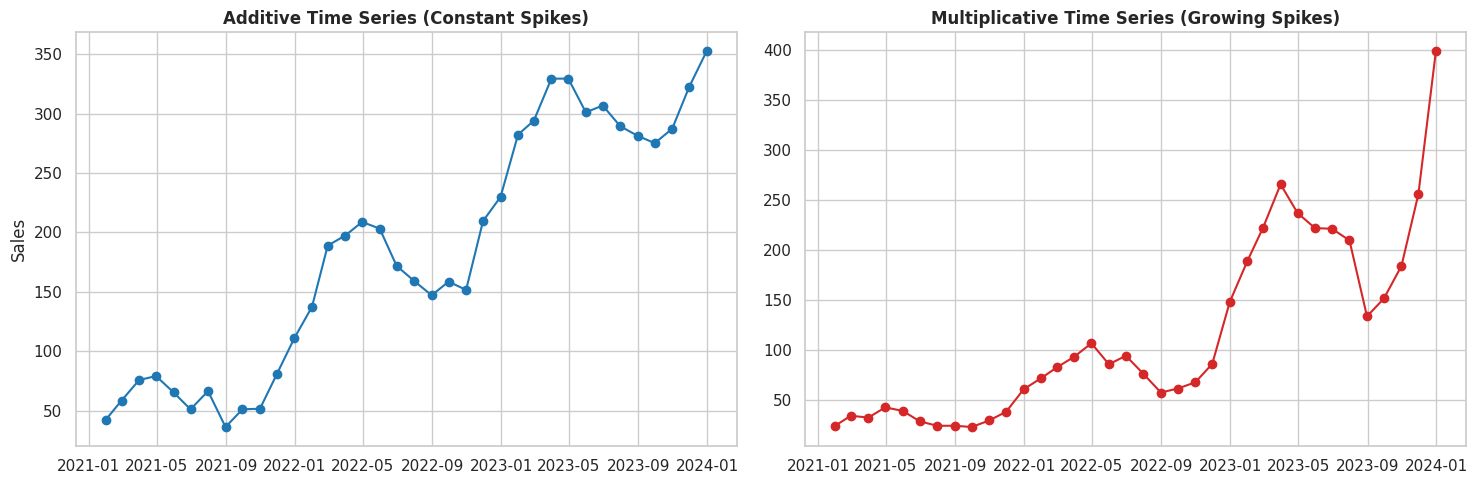

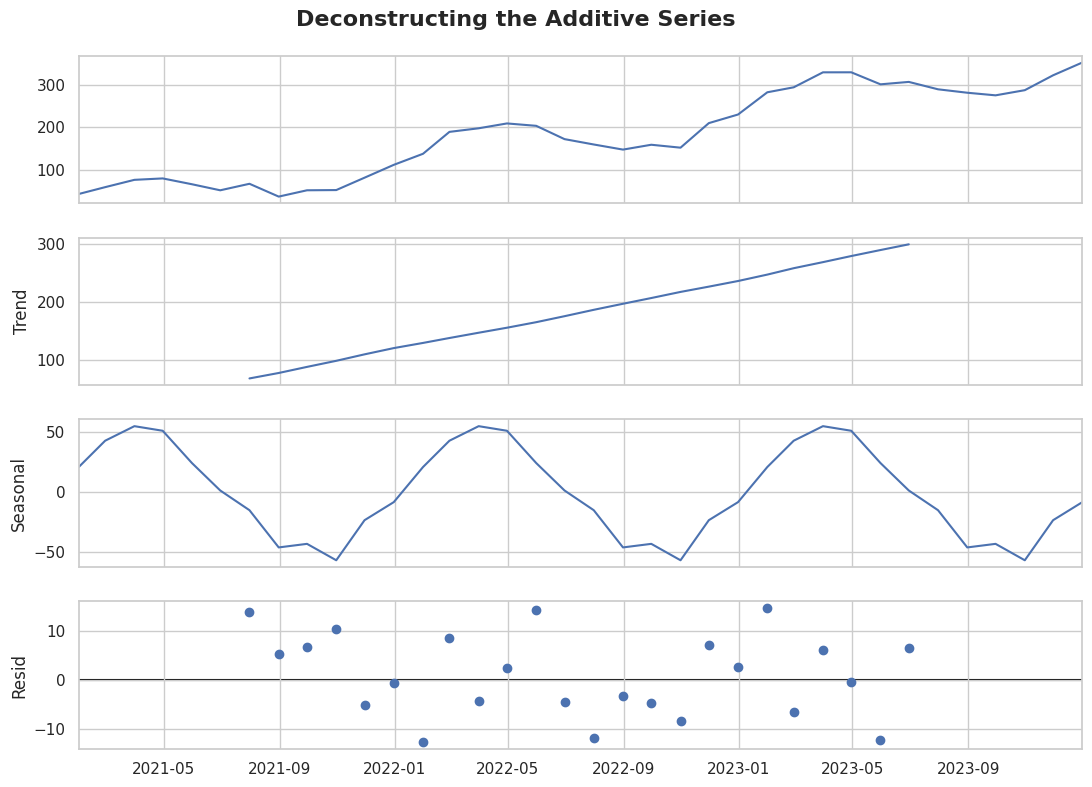

In [2]:
# 1. Simulate 3 years of monthly data (36 time steps)
t = np.arange(1, 37)
dates = pd.date_range(start='2021-01-01', periods=36, freq='M')

# 2. Create Additive Data (Constant Variance)
trend_add = t * 10
season_add = np.sin(t * (2 * np.pi / 12)) * 50  # Stable +/- 50 spike
noise_add = np.random.normal(0, 10, 36)
y_additive = trend_add + season_add + noise_add

# 3. Create Multiplicative Data (Growing Variance)
trend_mult = np.exp(t * 0.08) * 10 
season_mult = np.sin(t * (2 * np.pi / 12)) + 2  # Baseline of 2, scales the trend
noise_mult = np.random.normal(1, 0.1, 36)
y_multiplicative = trend_mult * season_mult * noise_mult

# Create DataFrames
df_add = pd.Series(y_additive, index=dates)
df_mult = pd.Series(y_multiplicative, index=dates)

# 4. Perform Classical Decomposition
# Note: You MUST define the period (e.g., 12 for monthly data, 7 for daily data)
decomp_add = seasonal_decompose(df_add, model='additive', period=12)
decomp_mult = seasonal_decompose(df_mult, model='multiplicative', period=12)

# 5. Matplotlib Visualization (Comparing the original signals)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(df_add.index, df_add, color='#1f77b4', marker='o')
axes[0].set_title("Additive Time Series (Constant Spikes)", fontweight='bold')
axes[0].set_ylabel("Sales")

axes[1].plot(df_mult.index, df_mult, color='#d62728', marker='o')
axes[1].set_title("Multiplicative Time Series (Growing Spikes)", fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Visualize the specific Additive Decomposition layers
fig = decomp_add.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Deconstructing the Additive Series', fontsize=16, fontweight='bold', y=1.02)
plt.show()

*(Insight: Look at the 4-panel decomposition chart. The algorithm successfully stripped out the $T_t$ (the smooth upward line) and the $S_t$ (the perfect sine wave). The bottom panel is the $R_t$ Residuals. If the decomposition is successful, the Residual panel should look like pure, random static centered around 0. If you see a pattern in the Residuals, your decomposition failed!)*

# 4. The Fatal Flaw of Classical Decomposition (Enter STL)

Classical `seasonal_decompose` has a massive flaw: **It assumes Seasonality never changes.** It calculates a single average seasonal spike and repeats it infinitely.

In reality, consumer behavior shifts. Perhaps your December retail spike is slowly smoothing out because people are shopping earlier in November. Classical decomposition cannot model this shifting behavior. Furthermore, it completely deletes the first 6 and last 6 data points of your dataset (returning `NaN`) because it relies on static moving averages.

The modern enterprise standard is **STL (Seasonal and Trend decomposition using Loess)**.
STL uses local regression (Loess) to allow both the Trend *and* the Seasonality to change dynamically over time. It handles outliers beautifully and never drops `NaN` values.

In [3]:
# Perform advanced STL Decomposition
# robust=True forces the algorithm to ignore wild outliers when calculating the trend
stl = STL(df_add, period=12, robust=True)
res = stl.fit()

print("🚨 Advanced STL Decomposition Complete.")
print("Unlike classical methods, STL captures dynamic, shifting seasonality without dropping edge data!")

🚨 Advanced STL Decomposition Complete.
Unlike classical methods, STL captures dynamic, shifting seasonality without dropping edge data!


## Real-World Use Case or Analogy:

Think of Decomposition like **Analyzing a Restaurant's Total Revenue**:

* **The Raw Data ($y_t$)**: The owner says, "We made $5,000 on Friday!"
* **The Trend ($T_t$)**: The neighborhood is gentrifying. Over the last 5 years, baseline revenue has grown smoothly by $200 a month.
* **The Seasonality ($S_t$)**: It was a Friday. Friday revenue is historically $+40\%$ higher than a Tuesday, strictly because of the weekend effect.
* **The Noise ($R_t$)**: It poured rain on that specific Friday, keeping 10 customers at home ($- \$300$).
* **The Intelligence**: By decomposing the number, the owner realizes the $5,000 wasn't an anomaly. It was exactly the expected mathematical combination of the upward trend, the Friday multiplier, and the negative weather noise.

---